# 5.1 Classification

Create a classification model using logistic regression.

* Reference: [LogisticRegression docs](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
* Train a model that classifies the type of flower using (i) 2 features (sepal length and width) and (ii) all 4 features. Create a testing dataset of 25% for validation.
* Visualize the model.
* Create a confusion matrix.
* Compute precision and recall for every class in your model.

In [1]:
!pip install scikit-learn matplotlib numpy pandas

In [2]:
%matplotlib inline
import os, sys
from sklearn import linear_model, datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

In [3]:
iris = datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df["target_name"]=iris['target_names'][iris_df['target']]
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [28]:
# Task 5.1: Classification
print("Task 5.1: Classification")
# I: only two features
print("Only two features")
# Select only 2 features as input (X) and target as output (y)
X_2features = iris_df[['sepal length (cm)', 'sepal width (cm)']]  # input x axis
y_2features = iris_df['target']   # Output y_axis
print(" X_2features:")
print(X_2features)
# Split into training and testing sets
# 25% for testing
X2f_train, X2f_test, y2f_train, y2f_test = train_test_split(
    X_2features, y_2features, test_size=0.25)
print("Print to check samples")
print("Training samples:",len(X2f_train))
print("Testing samples:",len(X2f_test))
# Create and train the logistic regression model
model_2 = linear_model.LogisticRegression(max_iter=1000)
model_2.fit(X2f_train, y2f_train)

# Predict on the test set
y2f_pred = model_2.predict(X2f_test)

# Measure accuracy
acc_2f = accuracy_score(y2f_test, y2f_pred)
print("Accuracy with 2 features:", acc_2f)
# Confusion matrix
print("Confusion matrix")
# Confusion matrix for 2-feature model
cm_2f = confusion_matrix(y2f_test, y2f_pred)

print("Confusion Matrix (2 features):")
print(cm_2f)



Task 5.1: Classification
Only two features
 X_2features:
     sepal length (cm)  sepal width (cm)
0                  5.1               3.5
1                  4.9               3.0
2                  4.7               3.2
3                  4.6               3.1
4                  5.0               3.6
..                 ...               ...
145                6.7               3.0
146                6.3               2.5
147                6.5               3.0
148                6.2               3.4
149                5.9               3.0

[150 rows x 2 columns]
Print to check samples
Training samples: 112
Testing samples: 38
Accuracy with 2 features: 0.8421052631578947
Confusion matrix
Confusion Matrix (2 features):
[[ 8  0  0]
 [ 0 11  3]
 [ 0  3 13]]


In [29]:
# II: only two features
print("All 4 features")
# Select all 4 features as input (X) and target as output (y)
X_4features = iris_df[['sepal length (cm)', 'sepal width (cm)',
               'petal length (cm)', 'petal width (cm)']] # input x axis
y_4features = iris_df['target']   # Output y_axis
X4f_train, X4f_test, y4f_train, y4f_test = train_test_split(
    X_4features, y_4features, test_size=0.25)
# Create and train the logistic regression model
model_4 = linear_model.LogisticRegression(max_iter=1000)
model_4.fit(X4f_train, y4f_train)
# Predict on the test set
y4f_pred = model_4.predict(X4f_test)

# Measure accuracy
acc_4f = accuracy_score(y4f_test, y4f_pred)
print("Accuracy with 4 features:", acc_4f)
# Confusion matrix
print("Confusion matrix")
# Confusion matrix for 2-feature model
cm_4f = confusion_matrix(y4f_test, y4f_pred)

print("Confusion Matrix (4 features):")
print(cm_4f)
print("The logistic regression model that uses all four features achieves better accuracy compared to the model trained with only two features. This indicates that petal measurements add valuable information for distinguishing between the different iris species.")



All 4 features
Accuracy with 4 features: 0.9473684210526315
Confusion matrix
Confusion Matrix (4 features):
[[18  0  0]
 [ 0 10  2]
 [ 0  0  8]]
The logistic regression model that uses all four features achieves better accuracy compared to the model trained with only two features. This indicates that petal measurements add valuable information for distinguishing between the different iris species.


In [ ]:
# 5.1.4/5
# Confusion matrix
print("Confusion matrix")
# Confusion matrix for 2-feature model
cm_2 = confusion_matrix(y2f_test, y2f_pred)

print("Confusion Matrix (2 features):")
print(cm_2)

In [31]:
from sklearn.metrics import classification_report
# Precision and recall for every class in your model.
print("Classification report (2 features):")
print(classification_report(y2f_test, y2f_pred, target_names=iris.target_names))

Classification report (2 features):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.79      0.79      0.79        14
   virginica       0.81      0.81      0.81        16

    accuracy                           0.84        38
   macro avg       0.87      0.87      0.87        38
weighted avg       0.84      0.84      0.84        38



In [32]:
# Precision and recall for every class in your model.
print("Classification report (4 features):")
print(classification_report(y4f_test, y4f_pred, target_names=iris.target_names))

# Precision tells us what proportion of the samples predicted as a given class truly belong to that class.
# Recall indicates how many of the actual samples of a class were correctly detected by the model.
# Both metrics are derived from the confusion matrix by examining true positives, false positives, and false negatives for each class.


Classification report (4 features):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        18
  versicolor       1.00      0.83      0.91        12
   virginica       0.80      1.00      0.89         8

    accuracy                           0.95        38
   macro avg       0.93      0.94      0.93        38
weighted avg       0.96      0.95      0.95        38



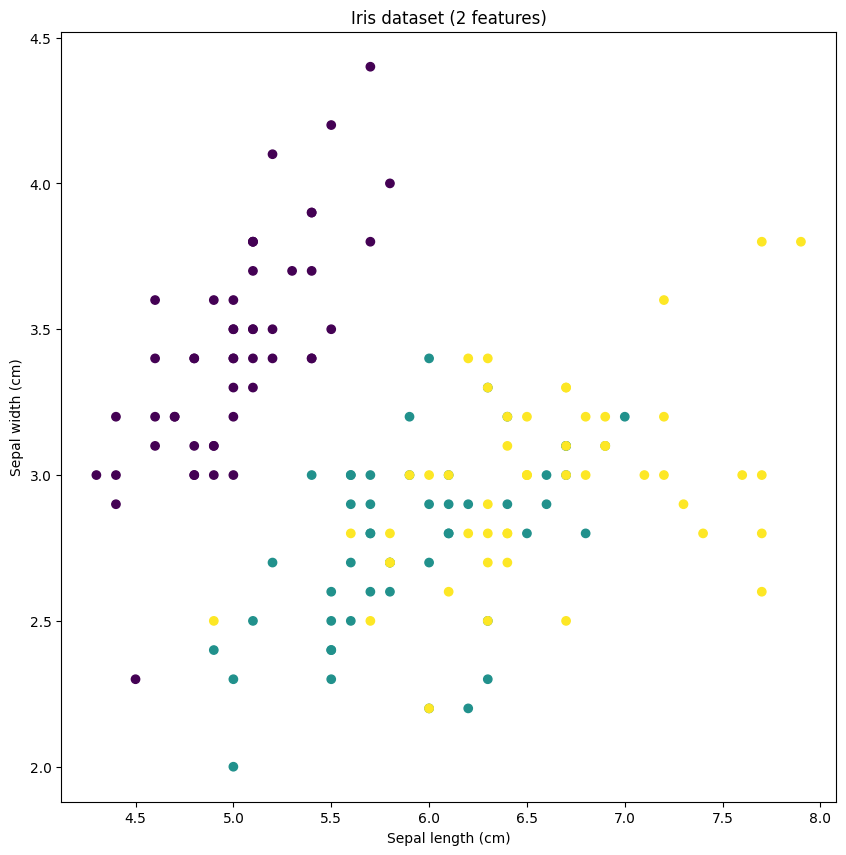

In [37]:
# Visualize the 2-feature dataset
plt.figure(figsize=(10,10))

plt.scatter(
    X_2features.iloc[:, 0],   # sepal length
    X_2features.iloc[:, 1],   # sepal width
    c=y_2features             # color by class
)

plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("Iris dataset 2 features")
plt.show()